# Data Preperation

### Import needed libraries

In [2]:
# import all the libraries i need
import os
os.makedirs('figures', exist_ok=True)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score
from sklearn.metrics import calinski_harabasz_score

import warnings
warnings.filterwarnings('ignore')

print('libraries loaded')

libraries loaded


### Loads Dataset

In [3]:
# load the dataset
# needed to specify encoding as latin1 to avoid errors with special characters  and also set InvoiceDate to string to avoid automatic conversion issues
df = pd.read_csv('Online Retail.csv', encoding='latin1', dtype={'InvoiceDate': str})
# check the shape
print('shape of dataset:', df.shape)

# look at first few rows
df.head()
# check column names and types
print(df.columns)
print()
print(df.dtypes)
# check for missing values
print('missing values in each column:')
print(df.isnull().sum())

shape of dataset: (541909, 8)
Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object
missing values in each column:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


### Data Pre-processing

In [4]:
# drops rows where CustomerID is missing
# CustomerID is essential for RFM analysis, so we need to drop rows where it's missing
df = df.dropna(subset=['CustomerID'])
print('rows after dropping missing CustomerID:', len(df))

rows after dropping missing CustomerID: 406829


In [5]:
# removes cancelled orders
# cancelled orders have invoice numbers starting with C
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
print('rows after removing cancellations:', len(df))

#remove rows with negative or zero quantity/price
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]
print('rows after removing bad quantity/price:', len(df))

# forced pandas to identify its a excel date format and converted it to datetime 
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'].astype(float), unit='D', origin='1899-12-30')

# check if it worked
print(df['InvoiceDate'].head())
print(df['InvoiceDate'].dtype)

#creates a TotalPrice column
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

# converts CustomerID to int
df['CustomerID'] = df['CustomerID'].astype(int)

#print summary to check everything looks good
print('done')
df.head()

rows after removing cancellations: 397924
rows after removing bad quantity/price: 397884
0   2010-12-01 08:26:00.096000293
1   2010-12-01 08:26:00.096000293
2   2010-12-01 08:26:00.096000293
3   2010-12-01 08:26:00.096000293
4   2010-12-01 08:26:00.096000293
Name: InvoiceDate, dtype: datetime64[ns]
datetime64[ns]
done


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00.096000293,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00.096000293,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00.096000293,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00.096000293,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00.096000293,3.39,17850,United Kingdom,20.34


In [6]:
# builds the RFM table
# snapshot date is the day after the last transaction
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print('snapshot date:', snapshot_date)

# groups by customer and calculates R, F, M
rfm = df.groupby('CustomerID').agg(
    Recency = ('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency = ('InvoiceNo', 'nunique'),
    Monetary = ('TotalPrice', 'sum')
).reset_index()

print('rfm table shape:', rfm.shape)
rfm.head()

# look at basic stats of rfm
rfm.describe()

snapshot date: 2011-12-10 12:49:59.808000285
rfm table shape: (4338, 4)


,CustomerID,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000,4338.000000
mean,15300.408022,92.536422,4.272015,2054.266460
std,1721.808492,100.014169,7.697998,8989.230441
min,12346.000000,1.000000,1.000000,3.750000
25%,13813.250000,18.000000,1.000000,307.415000
50%,15299.500000,51.000000,2.000000,674.485000
75%,16778.750000,142.000000,5.000000,1661.740000
max,18287.000000,374.000000,209.000000,280206.020000


In [7]:
# removes outliers by capping at 99th percentile 
for col in ['Recency', 'Frequency', 'Monetary']:
    cap_value = rfm[col].quantile(0.99)
    rfm[col] = rfm[col].clip(upper=cap_value)
    print(col, '- capped at:', round(cap_value, 2))

#scales the data to allow clustering to work better
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

Recency - capped at: 369.0
Frequency - capped at: 30.0
Monetary - capped at: 19881.0


# Data Exploration

number of unique invoices: 18532
sample values:
0    536365
1    536365
2    536365
3    536365
4    536365
Name: InvoiceNo, dtype: object


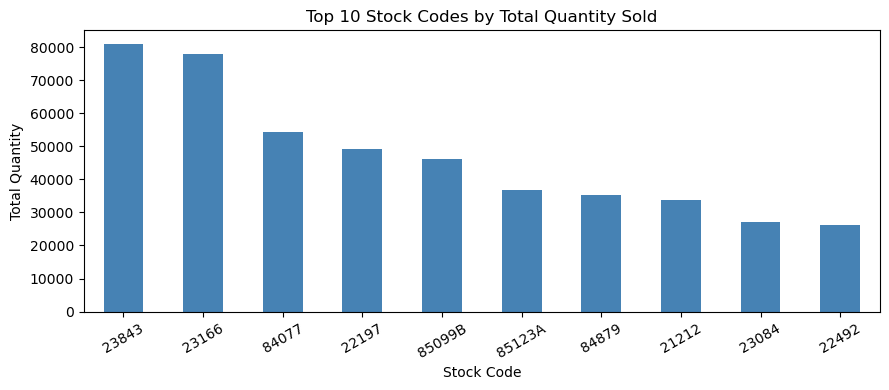

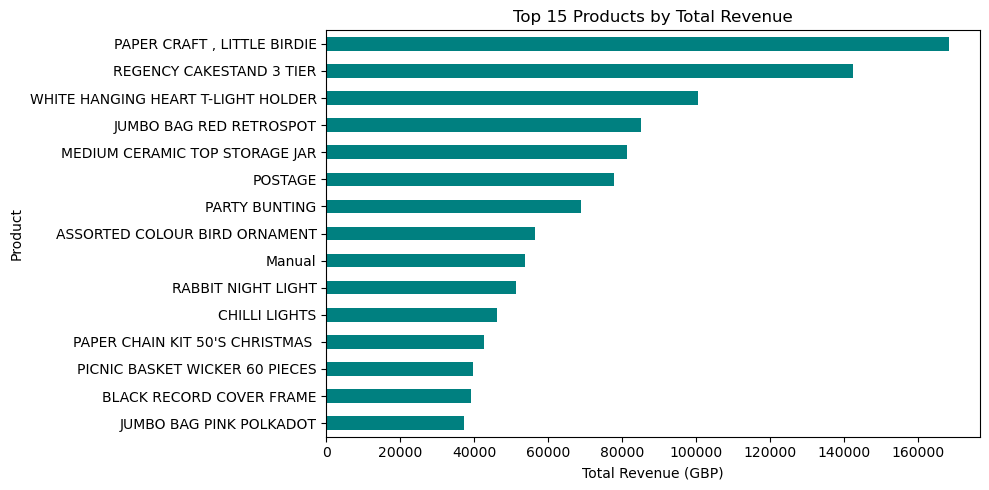

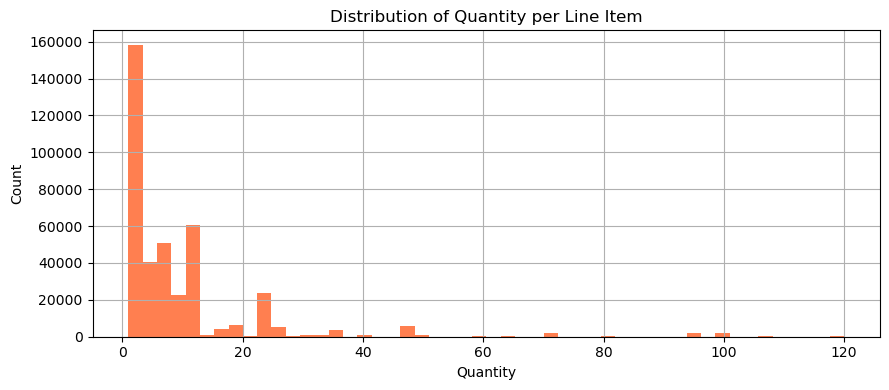

mean quantity: 12.99
median quantity: 6.0


In [8]:
# InvoiceNo - Column 1
# counts to check how many unique invoices there are
print('number of unique invoices:', df['InvoiceNo'].nunique())
print('sample values:')
print(df['InvoiceNo'].head())

# StockCode - Column 2
# displays the top 10 most sold products by quantity
top_stock = df.groupby('StockCode')['Quantity'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(9, 4))
top_stock.plot(kind='bar', color='steelblue')
plt.title('Top 10 Stock Codes by Total Quantity Sold')
plt.xlabel('Stock Code')
plt.ylabel('Total Quantity')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('figures/fig_stockcode.png')
plt.show()

# Description - column 3  
# displays the top 15 products by total revenue
top_products = df.groupby('Description')['TotalPrice'].sum().sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 5))
top_products.plot(kind='barh', color='teal')
plt.gca().invert_yaxis()
plt.title('Top 15 Products by Total Revenue')
plt.xlabel('Total Revenue (GBP)')
plt.ylabel('Product')
plt.tight_layout()
plt.savefig('figures/fig_top_products.png')
plt.show()


# Quantity - Column 4
# Histogram of quantity per line item, capped at 99th percentile to remove outliers
q_cap = df['Quantity'].quantile(0.99)

plt.figure(figsize=(9, 4))
df[df['Quantity'] <= q_cap]['Quantity'].hist(bins=50, color='coral')
plt.title('Distribution of Quantity per Line Item')
plt.xlabel('Quantity')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('figures/fig_quantity.png')
plt.show()

print('mean quantity:', round(df['Quantity'].mean(), 2))
print('median quantity:', df['Quantity'].median())


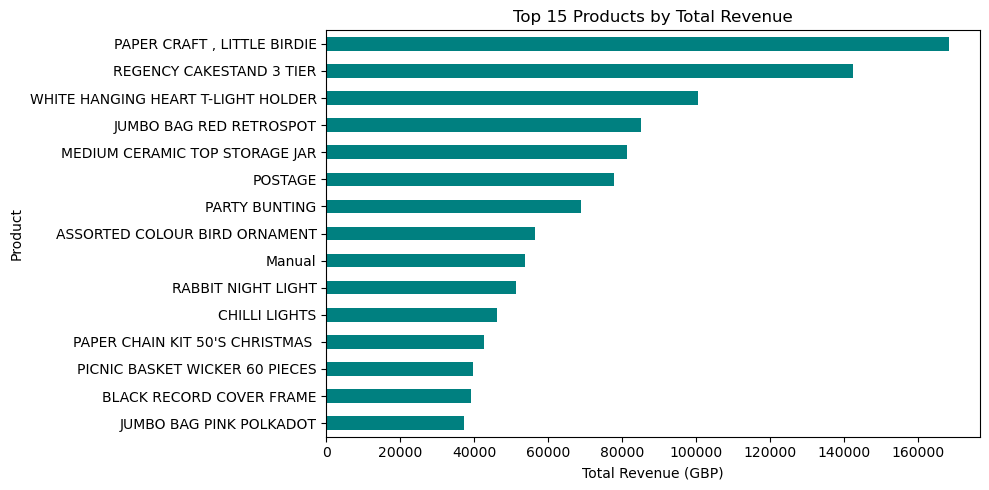

In [9]:
# Description - column 3  
# displays the top 15 products by total revenue
top_products = df.groupby('Description')['TotalPrice'].sum().sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 5))
top_products.plot(kind='barh', color='teal')
plt.gca().invert_yaxis()
plt.title('Top 15 Products by Total Revenue')
plt.xlabel('Total Revenue (GBP)')
plt.ylabel('Product')
plt.tight_layout()
plt.savefig('figures/fig_top_products.png')
plt.show()


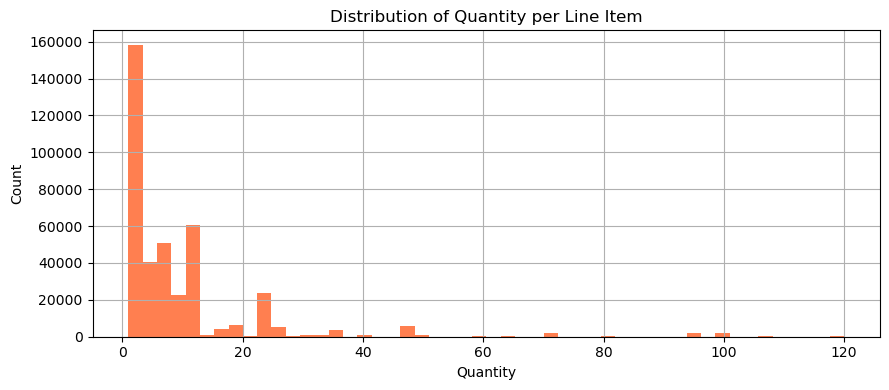

mean quantity: 12.99
median quantity: 6.0


In [10]:
# Quantity - Column 4
# uses a histogram to see the distribution, capped at 99th percentile to remove outliers
q_cap = df['Quantity'].quantile(0.99)

plt.figure(figsize=(9, 4))
df[df['Quantity'] <= q_cap]['Quantity'].hist(bins=50, color='coral')
plt.title('Distribution of Quantity per Line Item')
plt.xlabel('Quantity')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('figures/fig_quantity.png')
plt.show()

print('mean quantity:', round(df['Quantity'].mean(), 2))
print('median quantity:', df['Quantity'].median())

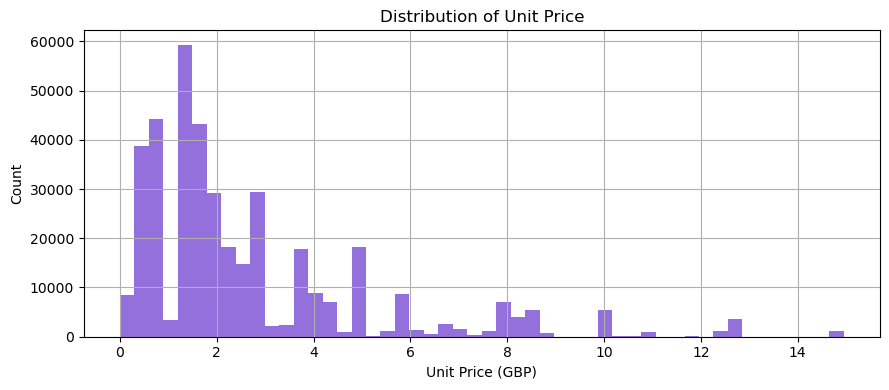

mean price: 3.12
median price: 1.95


In [11]:
#UnitPrice - Column 5
p_cap = df['UnitPrice'].quantile(0.99)

plt.figure(figsize=(9, 4))
df[df['UnitPrice'] <= p_cap]['UnitPrice'].hist(bins=50, color='mediumpurple')
plt.title('Distribution of Unit Price')
plt.xlabel('Unit Price (GBP)')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('figures/fig_unitprice.png')
plt.show()

print('mean price:', round(df['UnitPrice'].mean(), 2))
print('median price:', df['UnitPrice'].median())

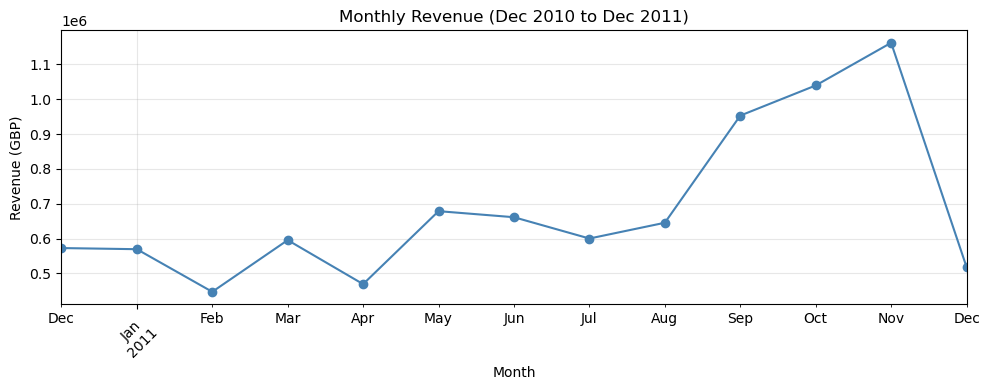

In [12]:
# InvoiceDate - monthly revenue over time - Column 6
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')
monthly = df.groupby('YearMonth')['TotalPrice'].sum()

plt.figure(figsize=(10, 4))
monthly.plot(marker='o', color='steelblue')
plt.title('Monthly Revenue (Dec 2010 to Dec 2011)')
plt.xlabel('Month')
plt.ylabel('Revenue (GBP)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/fig_monthly_revenue.png')
plt.show()

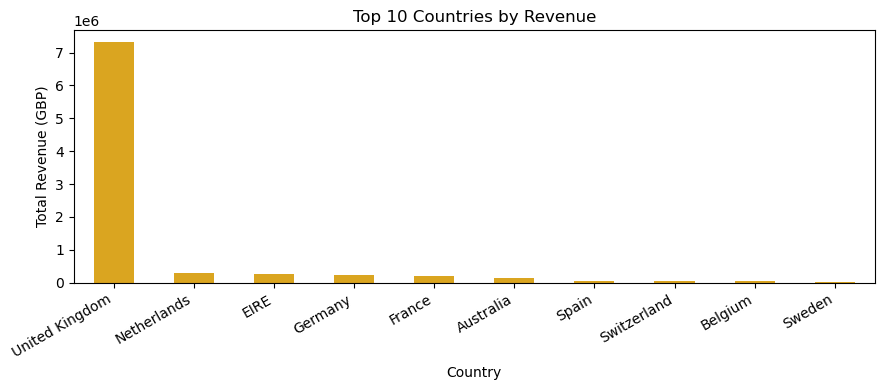

In [13]:
# country - top 10 by revenue - Column 7
country_rev = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(9, 4))
country_rev.plot(kind='bar', color='goldenrod')
plt.title('Top 10 Countries by Revenue')
plt.xlabel('Country')
plt.ylabel('Total Revenue (GBP)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('figures/fig_country.png')
plt.show()

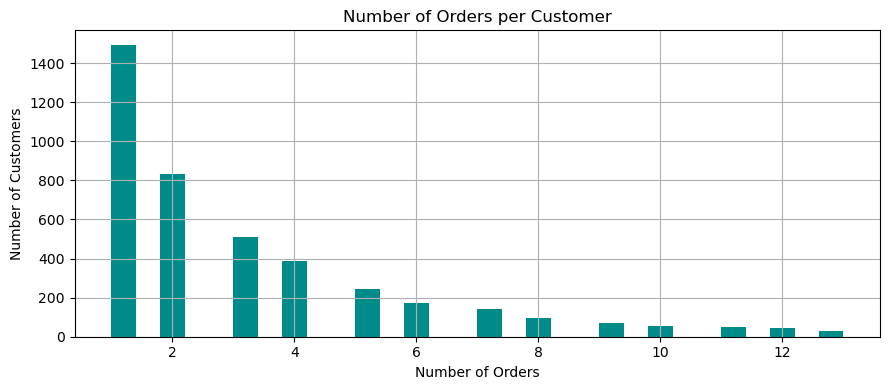

total unique customers: 4338
average orders per customer: 4.3


In [14]:
#CustomerID - how many orders per customer - Column 8
orders_per_customer = df.groupby('CustomerID')['InvoiceNo'].nunique()

plt.figure(figsize=(9, 4))
# cap at 95th percentile so histogram is readable
cap = orders_per_customer.quantile(0.95)
orders_per_customer[orders_per_customer <= cap].hist(bins=30, color='darkcyan')
plt.title('Number of Orders per Customer')
plt.xlabel('Number of Orders')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.savefig('figures/fig_orders_per_customer.png')
plt.show()

print('total unique customers:', len(orders_per_customer))
print('average orders per customer:', round(orders_per_customer.mean(), 1))

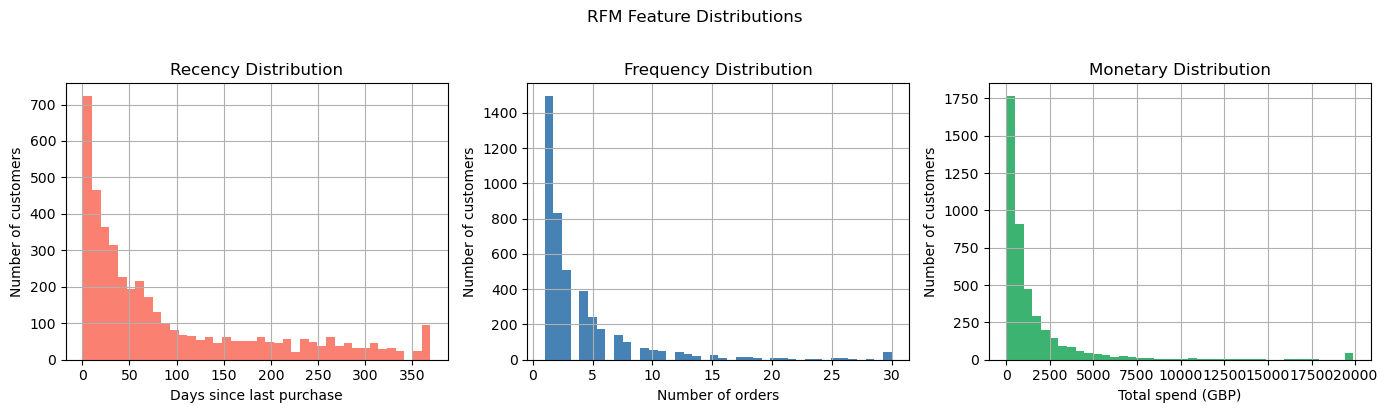

In [15]:
# RFM distributions - column 9
# plots all three RFM features side by side
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

rfm['Recency'].hist(bins=40, ax=axes[0], color='salmon')
axes[0].set_title('Recency Distribution')
axes[0].set_xlabel('Days since last purchase')
axes[0].set_ylabel('Number of customers')

rfm['Frequency'].hist(bins=40, ax=axes[1], color='steelblue')
axes[1].set_title('Frequency Distribution')
axes[1].set_xlabel('Number of orders')
axes[1].set_ylabel('Number of customers')

rfm['Monetary'].hist(bins=40, ax=axes[2], color='mediumseagreen')
axes[2].set_title('Monetary Distribution')
axes[2].set_xlabel('Total spend (GBP)')
axes[2].set_ylabel('Number of customers')

plt.suptitle('RFM Feature Distributions', y=1.02)
plt.tight_layout()
plt.savefig('figures/fig_rfm_distributions.png')
plt.show()

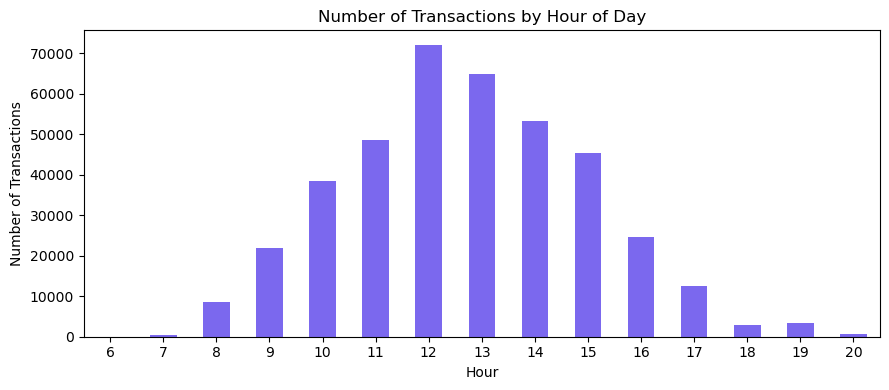

In [16]:
# Hour of day - Column 10
df['Hour'] = df['InvoiceDate'].dt.hour
hourly = df.groupby('Hour')['InvoiceNo'].count()

plt.figure(figsize=(9, 4))
hourly.plot(kind='bar', color='mediumslateblue')
plt.title('Number of Transactions by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('figures/fig_hourly.png')
plt.show()


**Task 2**

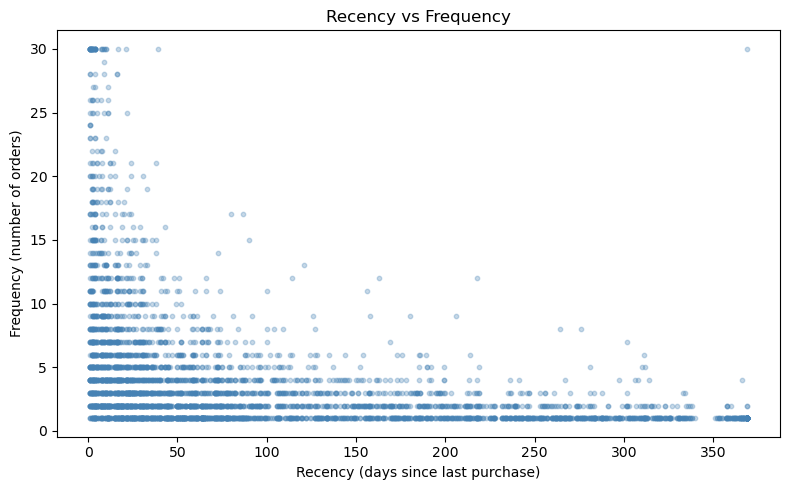

correlation: -0.365


In [17]:
#Plots receney vs frequency to see if there is any relationship 
plt.figure(figsize=(8, 5))
plt.scatter(rfm['Recency'], rfm['Frequency'], alpha=0.3, s=10, color='steelblue')
plt.title('Recency vs Frequency')
plt.xlabel('Recency (days since last purchase)')
plt.ylabel('Frequency (number of orders)')
plt.tight_layout()
plt.savefig('figures/fig_recency_frequency.png')
plt.show()

corr = rfm['Recency'].corr(rfm['Frequency'])
print('correlation:', round(corr, 3))

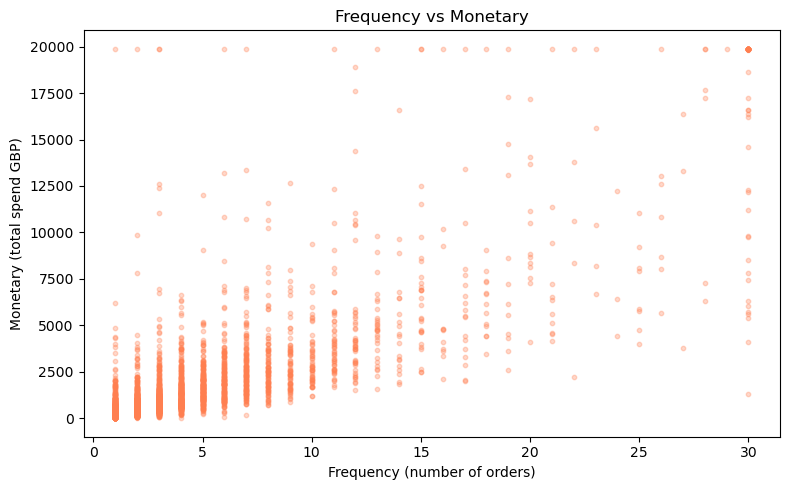

correlation: 0.79


In [18]:
# Plots Frequency vs Monetary

plt.figure(figsize=(8, 5))
plt.scatter(rfm['Frequency'], rfm['Monetary'], alpha=0.3, s=10, color='coral')
plt.title('Frequency vs Monetary')
plt.xlabel('Frequency (number of orders)')
plt.ylabel('Monetary (total spend GBP)')
plt.tight_layout()
plt.savefig('figures/fig_frequency_monetary.png')
plt.show()

corr = rfm['Frequency'].corr(rfm['Monetary'])
print('correlation:', round(corr, 3))

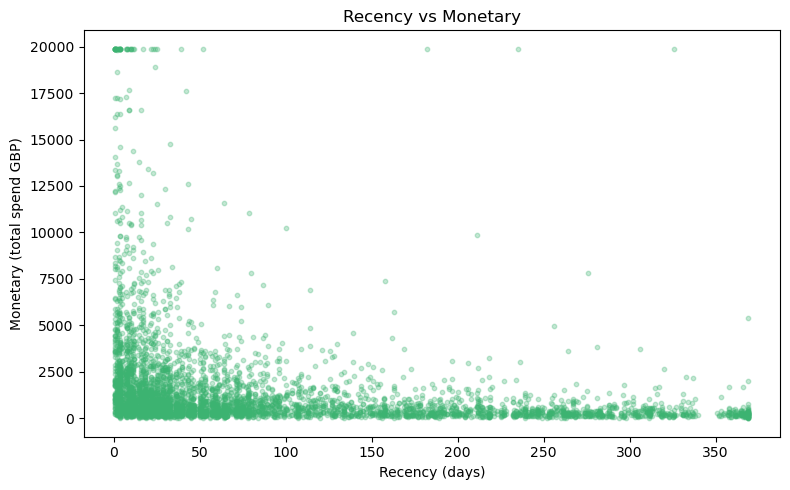

correlation: -0.275


In [19]:
# Plots  Recency vs Monetary
plt.figure(figsize=(8, 5))
plt.scatter(rfm['Recency'], rfm['Monetary'], alpha=0.3, s=10, color='mediumseagreen')
plt.title('Recency vs Monetary')
plt.xlabel('Recency (days)')
plt.ylabel('Monetary (total spend GBP)')
plt.tight_layout()
plt.savefig('figures/fig_recency_monetary.png')
plt.show()

corr = rfm['Recency'].corr(rfm['Monetary'])
print('correlation:', round(corr, 3))

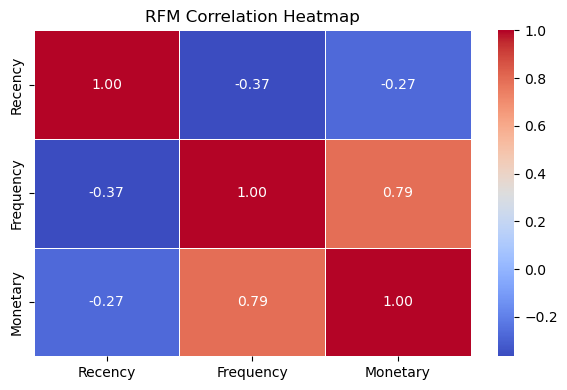

In [20]:
# RFM correlation heatmap

plt.figure(figsize=(6, 4))
corr_matrix = rfm[['Recency', 'Frequency', 'Monetary']].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('RFM Correlation Heatmap')
plt.tight_layout()
plt.savefig('figures/fig_rfm_heatmap.png')
plt.show()


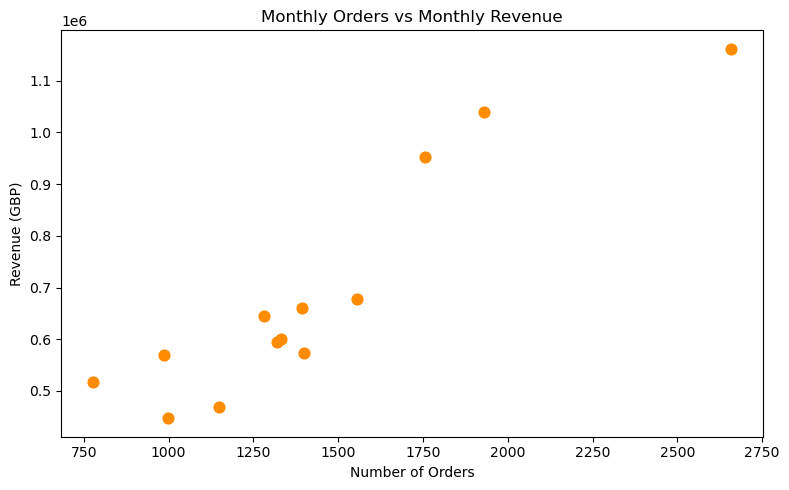

correlation: 0.925


In [21]:
# Monthly orders vs monthly revenue

monthly_orders = df.groupby('YearMonth')['InvoiceNo'].nunique()
monthly_revenue = df.groupby('YearMonth')['TotalPrice'].sum()

monthly_combined = pd.DataFrame({'Orders': monthly_orders, 'Revenue': monthly_revenue})

plt.figure(figsize=(8, 5))
plt.scatter(monthly_combined['Orders'], monthly_combined['Revenue'], color='darkorange', s=60)
plt.title('Monthly Orders vs Monthly Revenue')
plt.xlabel('Number of Orders')
plt.ylabel('Revenue (GBP)')
plt.tight_layout()
plt.savefig('figures/fig_orders_revenue.png')
plt.show()

corr = monthly_combined['Orders'].corr(monthly_combined['Revenue'])
print('correlation:', round(corr, 3))

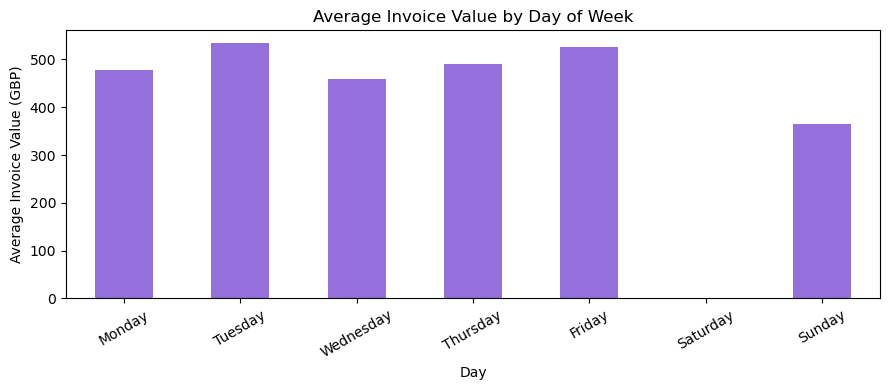

In [22]:
# Day of week vs average order value

df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# get average invoice value per day
invoice_by_day = df.groupby(['InvoiceNo', 'DayOfWeek'])['TotalPrice'].sum().reset_index()
avg_by_day = invoice_by_day.groupby('DayOfWeek')['TotalPrice'].mean().reindex(day_order)

plt.figure(figsize=(9, 4))
avg_by_day.plot(kind='bar', color='mediumpurple')
plt.title('Average Invoice Value by Day of Week')
plt.xlabel('Day')
plt.ylabel('Average Invoice Value (GBP)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('figures/fig_dayofweek.png')
plt.show()


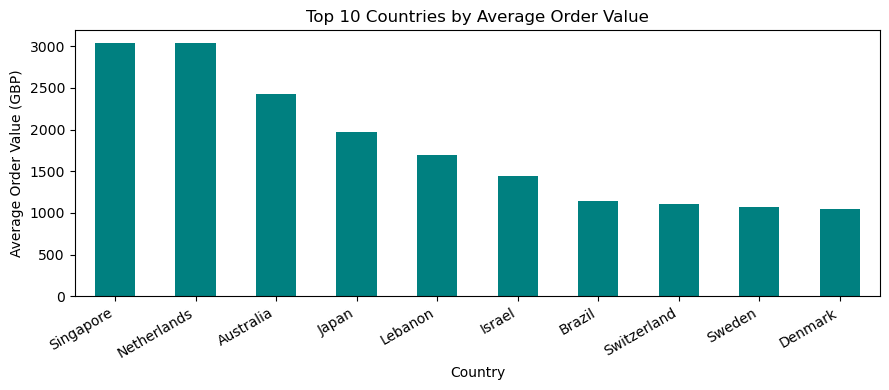

In [23]:
# Country vs average order value


invoice_totals = df.groupby(['InvoiceNo', 'Country'])['TotalPrice'].sum().reset_index()
avg_by_country = invoice_totals.groupby('Country')['TotalPrice'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(9, 4))
avg_by_country.plot(kind='bar', color='teal')
plt.title('Top 10 Countries by Average Order Value')
plt.xlabel('Country')
plt.ylabel('Average Order Value (GBP)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('figures/fig_country_avg.png')
plt.show()


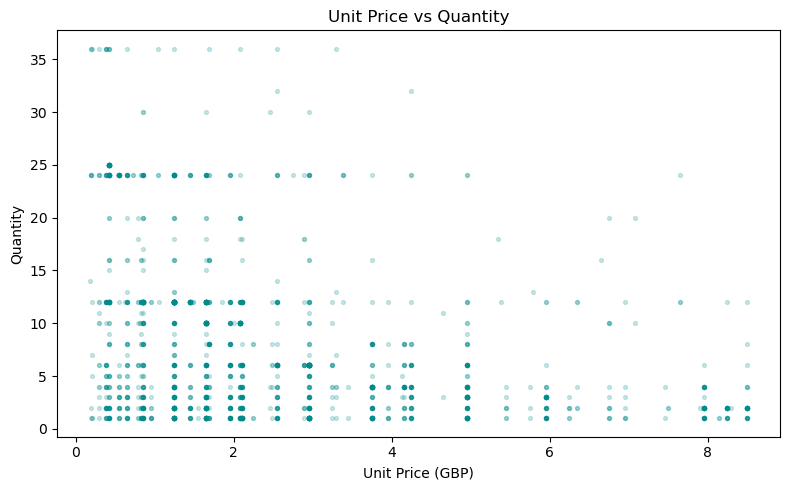

correlation: -0.005


In [24]:
# UnitPrice vs Quantity

# take a sample to make scatter plot readable
sample = df[
    (df['UnitPrice'] <= df['UnitPrice'].quantile(0.95)) &
    (df['Quantity'] <= df['Quantity'].quantile(0.95))
].sample(2000, random_state=42)

plt.figure(figsize=(8, 5))
plt.scatter(sample['UnitPrice'], sample['Quantity'], alpha=0.2, s=8, color='darkcyan')
plt.title('Unit Price vs Quantity')
plt.xlabel('Unit Price (GBP)')
plt.ylabel('Quantity')
plt.tight_layout()
plt.savefig('figures/fig_price_quantity.png')
plt.show()

corr = df['UnitPrice'].corr(df['Quantity'])
print('correlation:', round(corr, 3))



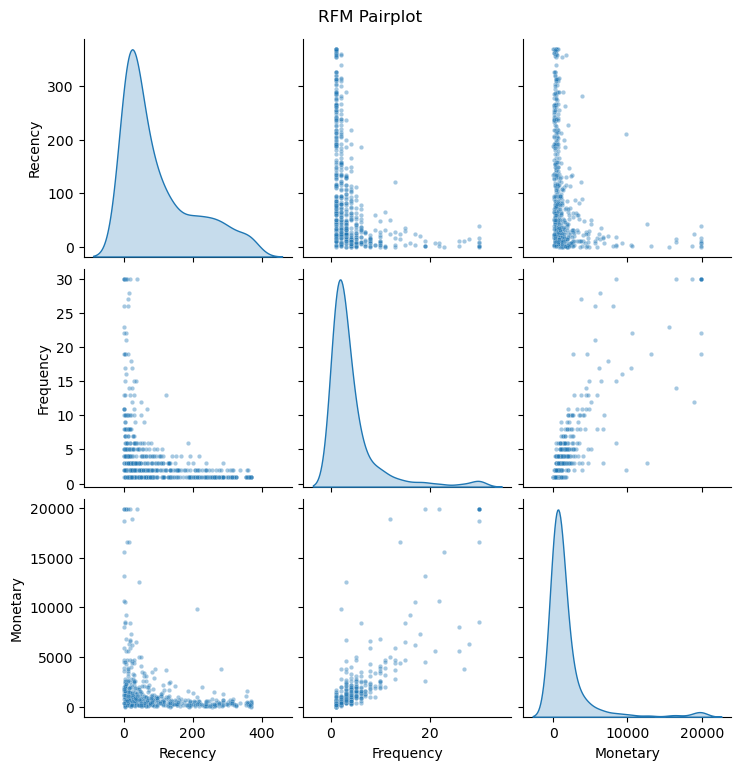

In [25]:
# RFM pairplot

# uses a sample of 500 customers so it runs faster
rfm_sample = rfm[['Recency', 'Frequency', 'Monetary']].sample(500, random_state=42)

pair_plot = sns.pairplot(rfm_sample, diag_kind='kde', plot_kws={'alpha': 0.4, 's': 10})
pair_plot.figure.suptitle('RFM Pairplot', y=1.02)
plt.savefig('figures/fig_rfm_pairplot.png')
plt.show()


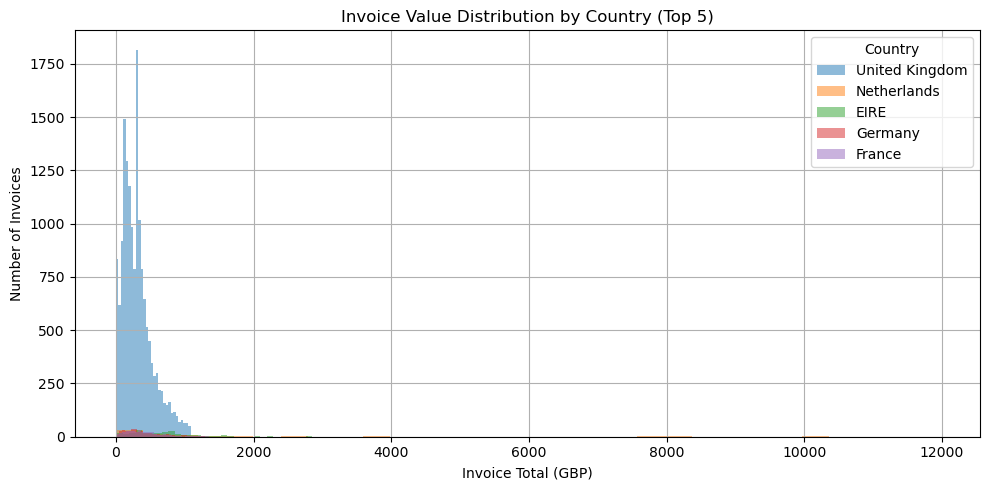

In [26]:
# Invoice value for UK vs top international countries


top5 = df.groupby('Country')['TotalPrice'].sum().nlargest(5).index.tolist()
invoice_country = df[df['Country'].isin(top5)].groupby(['InvoiceNo', 'Country'])['TotalPrice'].sum().reset_index()

plt.figure(figsize=(10, 5))
for country in top5:
    vals = invoice_country[invoice_country['Country'] == country]['TotalPrice']
    cap = vals.quantile(0.95)
    vals[vals <= cap].hist(bins=30, alpha=0.5, label=country)
plt.title('Invoice Value Distribution by Country (Top 5)')
plt.xlabel('Invoice Total (GBP)')
plt.ylabel('Number of Invoices')
plt.legend(title='Country')
plt.tight_layout()
plt.savefig('figures/fig_invoice_country.png')
plt.show()


#  Models: K-means and DBSCAN

In [35]:
#import KMeans for clustering
from sklearn.cluster import KMeans

# To find the best value of k, using the elbow method, silhouette score, and Davies-Bouldin score

inertia_values = []
silhouette_values = []
db_values = []

k_range = range(2, 11)

for k in k_range:
    # trains the KMeans model and gets the cluster labels
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(rfm_scaled)
    
    # keeps track of the scores for each k
    inertia_values.append(km.inertia_)
    silhouette_values.append(silhouette_score(rfm_scaled, labels))
    db_values.append(davies_bouldin_score(rfm_scaled, labels))

print('done testing k values from 2 to 10')

done testing k values from 2 to 10


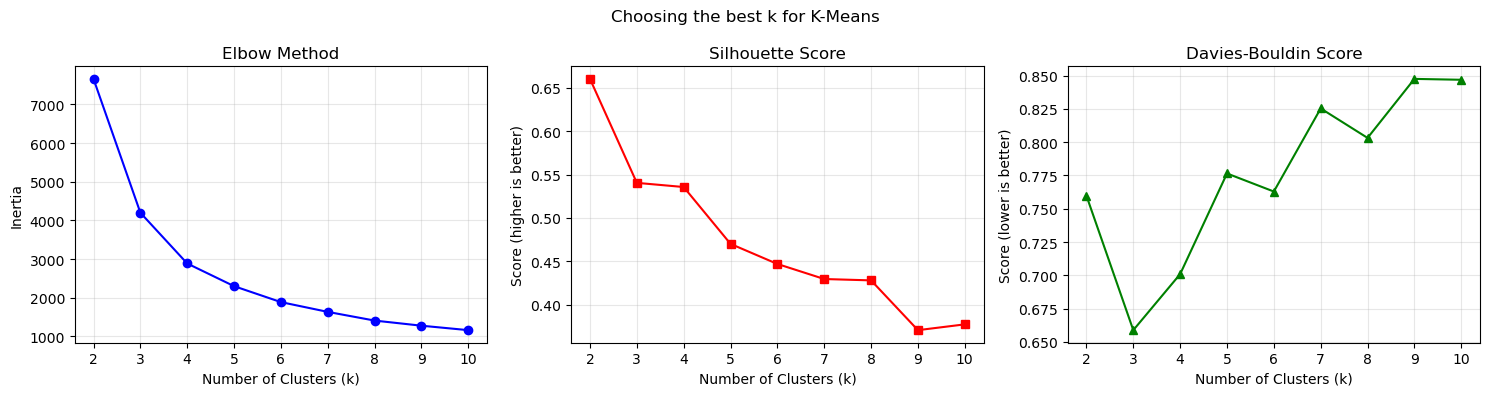

k  | silhouette | davies-bouldin
 2 | 0.6602     | 0.7598
 3 | 0.5405     | 0.6589
 4 | 0.5357     | 0.7010
 5 | 0.4701     | 0.7765
 6 | 0.4470     | 0.7629
 7 | 0.4297     | 0.8253
 8 | 0.4281     | 0.8032
 9 | 0.3708     | 0.8475
10 | 0.3774     | 0.8468


In [37]:
# plots elbow method
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.plot(k_range, inertia_values, 'bo-')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.plot(k_range, silhouette_values, 'rs-')
plt.title('Silhouette Score')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Score (higher is better)')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
plt.plot(k_range, db_values, 'g^-')
plt.title('Davies-Bouldin Score')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Score (lower is better)')
plt.grid(True, alpha=0.3)

plt.suptitle('Choosing the best k for K-Means')
plt.tight_layout()
plt.savefig('figures/fig_kmeans_k.png')
plt.show()

# prints the scores
print('k  | silhouette | davies-bouldin')
for k, s, db in zip(k_range, silhouette_values, db_values):
    print(f'{k:2d} | {s:.4f}     | {db:.4f}')

In [ ]:
# trains the final kmeans model with k=4
k = 4
km_model = KMeans(n_clusters=k, random_state=42, n_init=10)
rfm['KMeans_Cluster'] = km_model.fit_predict(rfm_scaled)

print('K-Means trained with k =', k)
print()
print('cluster sizes:')
print(rfm['KMeans_Cluster'].value_counts().sort_index())

K-Means trained with k = 4

cluster sizes:
KMeans_Cluster
0     107
1    1038
2     554
3    2639
Name: count, dtype: int64


In [ ]:
# evaluates the model
km_silhouette = silhouette_score(rfm_scaled, rfm['KMeans_Cluster'])
km_db = davies_bouldin_score(rfm_scaled, rfm['KMeans_Cluster'])
km_ch = calinski_harabasz_score(rfm_scaled, rfm['KMeans_Cluster'])

print('K-Means Evaluation Results:')
print('Silhouette Score:', round(km_silhouette, 4), '(higher is better, max is 1)')
print('Davies-Bouldin Score:', round(km_db, 4), '(lower is better)')
print('Calinski-Harabasz Score:', round(km_ch, 2), '(higher is better)')

K-Means Evaluation Results:
Silhouette Score: 0.5357 (higher is better, max is 1)
Davies-Bouldin Score: 0.701 (lower is better)
Calinski-Harabasz Score: 5070.06 (higher is better)


In [ ]:
# looks at the average RFM values per cluster
km_profile = rfm.groupby('KMeans_Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(1)
km_profile['Count'] = rfm.groupby('KMeans_Cluster')['CustomerID'].count()
print('Average RFM values per cluster:')
print(km_profile)

Average RFM values per cluster:
                Recency  Frequency  Monetary  Count
KMeans_Cluster                                     
0                  18.2       23.8   15279.8    107
1                 250.4        1.5     441.8   1038
2                  21.8       10.7    4324.1    554
3                  48.2        2.8     926.7   2639


In [ ]:
# Assigns segment labels based on the average RFM values per cluster
r_rank = km_profile['Recency'].rank()
f_rank = km_profile['Frequency'].rank(ascending=False)
combined_rank = (r_rank + f_rank).sort_values()
sorted_clusters = combined_rank.index.tolist()

label_map = {
    sorted_clusters[0]: 'Champions',
    sorted_clusters[1]: 'Loyal Customers',
    sorted_clusters[2]: 'At-Risk',
    sorted_clusters[3]: 'Lost/Inactive'
}

rfm['KMeans_Label'] = rfm['KMeans_Cluster'].map(label_map)

print('Segment counts:')
print(rfm['KMeans_Label'].value_counts())

Segment counts:
KMeans_Label
At-Risk            2639
Lost/Inactive      1038
Loyal Customers     554
Champions           107
Name: count, dtype: int64


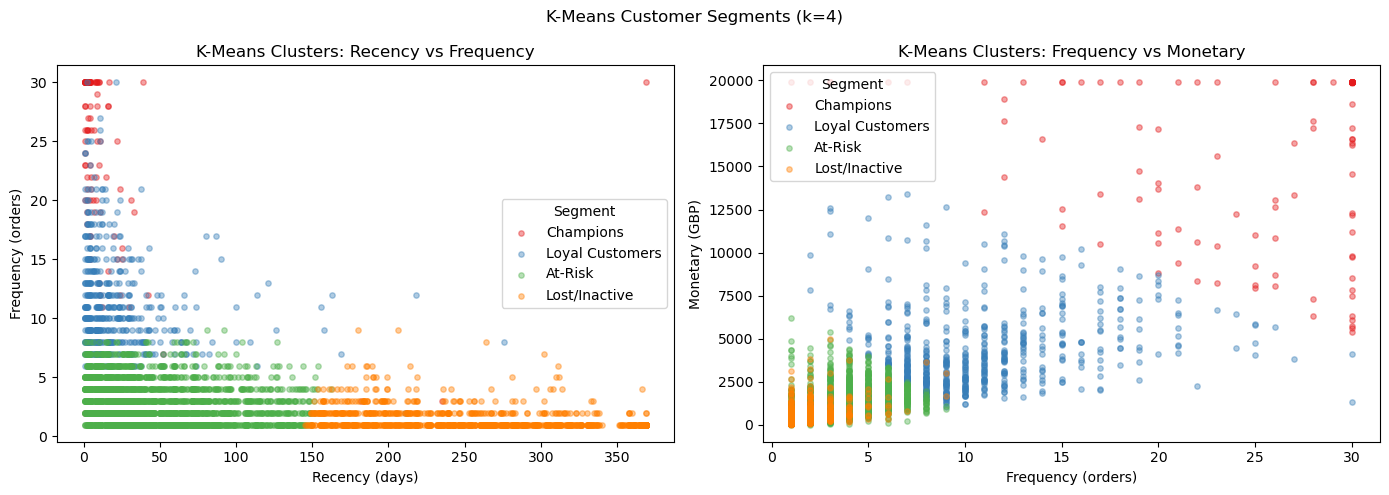

In [38]:
# visualises the clusters
colors = ['#e41a1c', '#377eb8', '#4daf4a', '#ff7f00']
labels = rfm['KMeans_Label'].unique()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label, color in zip(labels, colors):
    mask = rfm['KMeans_Label'] == label
    axes[0].scatter(rfm.loc[mask, 'Recency'], rfm.loc[mask, 'Frequency'],
                    alpha=0.4, s=15, label=label, color=color)
    axes[1].scatter(rfm.loc[mask, 'Frequency'], rfm.loc[mask, 'Monetary'],
                    alpha=0.4, s=15, label=label, color=color)

axes[0].set_title('K-Means Clusters: Recency vs Frequency')
axes[0].set_xlabel('Recency (days)')
axes[0].set_ylabel('Frequency (orders)')
axes[0].legend(title='Segment')

axes[1].set_title('K-Means Clusters: Frequency vs Monetary')
axes[1].set_xlabel('Frequency (orders)')
axes[1].set_ylabel('Monetary (GBP)')
axes[1].legend(title='Segment')

plt.suptitle('K-Means Customer Segments (k=4)')
plt.tight_layout()
plt.savefig('figures/fig_kmeans_clusters.png')
plt.show()